<a href="https://colab.research.google.com/github/sergejlembke/aki-ml/blob/main/p7/23_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Machine Learning
### Sommersemester 2026
Prof. Dr. Stefan Goetze

# Transfer Learning mit TensorFlow

basiert auf dem Google Beispiel [*Transfer learning with TensorFlow Hub*](https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub)
(Tensorflow, 2018, Apache 2.0 Lizenz)

In [53]:
import numpy as np
import time
import os

import PIL.Image as Image
import matplotlib.pylab as plt

try:
    import tensorflow as tf
    import tensorflow_hub as hub
except:
    import sys
    !{sys.executable} -m pip install --upgrade tensorflow tensorflow_hub
    import tensorflow as tf
    import tensorflow_hub as hub


version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
    import tf_keras as keras
else:
    keras = tf.keras

## Ein vortrainiertes ImageNet Modell verwenden

Nicht immer müssen Modelle selbst trainiert werden.
Zu verschiedene Anwendungsbereichen gibt es vortrainierte Modelle, die man direkt verwenden kann.
Ein Beispiel ist die Bildklassifikation.
Es gibt einige bekannte Neuronale Faltungsnetze (z.B. *Inception*, *ResNet*, *MobileNet* ...) die für die Klassifikation von Bildern eingesetzt werden können.
Wir wollen ein solches, vortrainiertes Modell verwenden, um zu erkennen, welches Objekt auf einem Foto agebildet ist.

### Ein Modell auswählen

Für diese Demo werden wir ein [MobileNetV2 Model](https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/2) von [TensorFlow Hub](https://www.tensorflow.org/hub) verwenden.
Auf dieser Plattform gibt es [viele weitere Modelle](https://tfhub.dev/s?q=tf2&module-type=image-classification), die man ebenfalls zur für diese Bildklassifikationsaufgabe verwenden könnte.


In [54]:
classifier_model ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"

In [55]:
IMAGE_SHAPE = (224, 224)

classifier = keras.Sequential([
    hub.KerasLayer(classifier_model, input_shape=IMAGE_SHAPE+(3,))
])

### Eine Bildklassifikation durchführen

Als Erstes wollen wir das Modell ausprobieren.
Wir laden ein Bild aus dem Netz herunter und skalieren es auf die vom Modell verwendete Bildgröße.


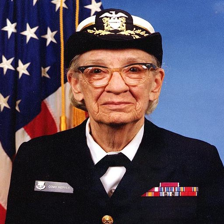

In [56]:
sample_img = tf.keras.utils.get_file('image.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg')

sample_img = Image.open(sample_img).resize(IMAGE_SHAPE)
sample_img

Nun machen wir aus dem Bild ein Numpy Array

In [57]:
oldtype = type(sample_img)
sample_img = np.array(sample_img)/255.0
newtype = type(sample_img)
print(f"Von {oldtype} zu {newtype}")
sample_img.shape

Von <class 'PIL.Image.Image'> zu <class 'numpy.ndarray'>


(224, 224, 3)

Wir sehen, dass unser Bild nun als 3-Tupel abgespeichert ist.
Die einzelnen Dimensionen sind die Höhe und Breite des Bildes (je $224$) sowie die einzelnen Pixelwerte ($3$).
Das MobileNet Modell kann allerdings auf einen ganzen *Batch* von Bildern gleichzeitig angewendet werden und erwartet daher in der ersten Dimension die ID des Bildes.
Wir müssen also aus dem 3-Tupel ein 4-Tupel machen, wobei die erste Dimension keine Daten enthält

In [58]:
input_image = sample_img.reshape(-1,*IMAGE_SHAPE,3)
result = classifier.predict(input_image)
result.shape

1/1 [==============================] - 1s 522ms/step


(1, 1001)

Das Resultat der Vorhersage ist ein Vektor mit 1001 Einträgen.
Jeder Eintrag beinhaltet den *Logit*-Wert für eine bestimmte Klasse von Objekten.
Zur Erinnerung: Ein Logit ist der natürliche Logarithmus einer Chance, wobei die Chance $\frac{p}{1-p}$ als Wahrscheinlichkeit $p$ durch Gegenwahrscheinlichkeit $1-p$ definiert ist.

Um die *wahrscheinlichste* Klasse zu bestimmen, muss man also den Index des Maximums in diesem Array finden.
Das funktioniert in NumPy mit der `argmax` Funktion:

In [59]:
predicted_class = np.argmax(result[0], axis=-1)
predicted_class

np.int64(653)

### Die Vorhersage dekodieren

Nun möchten wir natürlich noch wissen, welche Klasse hinter der ID steckt.
Da MobileNEt ein Klassifikator für den `ImageNet` Datensatz ist, können wir die Klassen von ImageNet zurate ziehen:

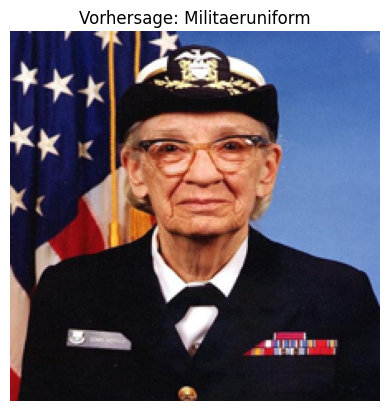

In [60]:
labels_path = tf.keras.utils.get_file('ImageNetLabels.txt','https://github.com/fhswf/datasets/raw/main/ImageNetLabelsDe.txt')
imagenet_labels = np.array(open(labels_path).read().splitlines())
plt.imshow(sample_img)
plt.axis('off')
predicted_class_name = imagenet_labels[predicted_class]
plt.title("Vorhersage: " + predicted_class_name.title());

**Aufgabe:** Bestimmen Sie die Klassen mit zweit- bis fünfhöchsten Wahrscheinlichkeit (bzw. Logits).
Um diese Klassen zu bestimmen, ist die NumPy Funktion `np.argsort` hilfreich. Sie sortiert das Array aufsteigend, gibt aber die ursprünglichen Indizes der sortierten Daten zurück und nicht deren Werte.
Beachten Sie, dass Result ein zweidimensionales Array ist.
Übergeben Sie also am einfachsten das Teil-Array `result[0]` an `np.argsort`.


In [61]:
predicted_classes_top5 = np.argsort(result[0], axis=-1)[::-1][:5]
predicted_classes_top5

array([653, 440, 668, 835, 982])

In [62]:
predicted_classes_top5_names = imagenet_labels[predicted_classes_top5]
predicted_classes_top5_names

array(['Militaeruniform', 'Baerenfell', 'Doktorhut', 'Anzug',
       'Baseballspieler'], dtype='<U38')

##  Transfer Learning mit Tensorflow

Wir haben nun gesehen, das wir MobileNet zum Klassifizieren von Bildern verwenden können.
Allerdings wird uns dieses (und alle weiteren für den ImageNet Datensatz trainierte Modelle) nur eine Klasse vorhersagen, die in den ursprünglichen 1000 Kategorien.
(Die 1001 Kategorie ist übrigens für die Klasse *nicht bestimmbar* bestimmt. Diese wird aber i.d.R. nicht verwendet.)

Nun stellt sich die Frage, wie man Objekte klassifizieren kann, die im ursprünglichen Datensatz nicht enthalten sind, bzw. deren Label nicht vorkommen.
Eine naiver Ansatz wäre, einen neuen Trainingsdatensatz mit allen Bildern (also der ImageNet Bilder und der *eigenen* Bilder) zu erstellen, und ein neues Netz zu trainieren.
Das wäre sehr zeitaufwendig, da das Neuronale Netz *von Grund auf neu Lernen* müsste.
Und eigentlich haben wir Ja schon ein Netz, das Bilder unterscheiden kann.
Wir wollen diesem Netz nur die *zusätzlichen Kategorien beibringen*.

Genau dies ist der Ansatz von **Transfer Learning**.
Wir nehmen ein bestehendes, trainiertes Modell (z.B. MobileNet) und verändern nur die hinteren Schichten, sodass das Netz die neuen Kategorien zu unterscheiden lernt.

### Eigener Datensatz

Für dieses Beispiel verwenden wir den Tensorflow *Flowers* Datensatz in dem verschiedene Arten von Blumen enthalten sind.
Wir laden ihn aus dem Netz herunter und erstellen einen Trainingsdatensatz, indem wir die Methode `image_dataset_from_directory` mit dem Ornernamen der entpackten Bilder aufrufen.

In [63]:
data_root = tf.keras.utils.get_file(
  'flower_photos','https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
   untar=True)

# Adjust data_root to point to the actual directory containing class folders
data_root = os.path.join(data_root, 'flower_photos')

batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  str(data_root),
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


Der Datensatz beinhaltet 5 Arten von Blumen.
Die Namen der Klassen benennen wir hier ins Deutsche um.

In [64]:
class_names = np.array(train_ds.class_names)
print("Klassen (englisch):", class_names)
train_ds.class_names = ['Gaensebluemchen', 'Loewenzahn', 'Rosen', 'Sonnenblumen', 'Tulpen']
class_names = np.array(train_ds.class_names)
print("Klassen (deutsch):", train_ds.class_names)

Klassen (englisch): ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']
Klassen (deutsch): ['Gaensebluemchen', 'Loewenzahn', 'Rosen', 'Sonnenblumen', 'Tulpen']


Die Daten unserer Bilder sind Pixelwerte im Integer Format, die TensorFlow Hub Modelle für Bildverarbeitung erwarten allerdings Fließkommazahlen im Bereich `[0, 1]`.
Wir verwenden hier `Rescaling` aus dem Modul `tf.keras.layers.experimental.preprocessing` um die Daten zu transformieren.

In [65]:
from tensorflow.keras.layers import Rescaling
img_scaler = Rescaling(1.0/255)
train_ds = train_ds.map(lambda x, y: (img_scaler(x), y))

Die nächsten beiden Anweisungen dienen der Performance Verbesserung beim Trainieren.
Tensorflow soll die Bilder, die als nächstes VErarbeitet werden bereits vorab laden.
Dieses Prinzip heißt *Prefetching* und wird allgemein eingesetzt um Wartezeiten für Eingabe-Operationen möglichst zu vermeiden.

In [66]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

Wir können nun die Bilddaten (effizient) Batch-weise verarbeiten.
In der folgenden Code-Zelle TEsten wir eine Schleife die die Bild-Daten durchlaufen würde und geben uns die Dimensionen des Batches und der Label aus.
Nach dem ersten Durchlauf beenden wir die Schleife und haben einen Satz von Bildern und Labels unter den Referenzen `image_batch` bzw. `labels_batch` geladen.

In [67]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape, labels_batch)
    break

(32, 224, 224, 3)
(32,) tf.Tensor([2 1 4 3 1 2 1 2 4 1 4 4 3 4 1 2 0 4 1 1 1 4 3 2 3 1 4 2 2 3 4 3], shape=(32,), dtype=int32)


### Normales ImageNet Modell auf eigene Daten anwenden

Bevor wir ein neues Modell trainieren, wollen wir prüfen, wie unser MobileNet Modell mit den Blumen-Datensatz klar kommt.

In [68]:
result_batch = classifier.predict(image_batch)

1/1 [==============================] - 0s 43ms/step


In [69]:
predicted_class_names = imagenet_labels[np.argmax(result_batch, axis=-1)]
predicted_class_names

array(['Fussmatte', 'Korallenriff', 'Seejungfer', 'Gaensebluemchen',
       'Gaensebluemchen', 'Gewaechshaus', 'Stachelschweine', 'braeutigam',
       'Gewaechshaus', 'Federkiel Federkiel', 'Mais', 'Lattenzaun',
       'Gaensebluemchen', 'Tritonshorn', 'cardoon', 'Vase',
       'Gaensebluemchen', 'Sockel', 'Gaensebluemchen', 'Besen', 'cardoon',
       'Windrad', 'Rosskastanie', 'Militaeruniform', 'braeutigam',
       'Bedlington Terrier', 'Schneckenzaun', 'Blumenkohl', 'Kolibri',
       'Gaensebluemchen', 'Gaensebluemchen', 'Gaensebluemchen'],
      dtype='<U38')

Wir können nun prüfen, welche Ausgaben das Modell für unsere Blumenbilder vorhersagt.
ImageNet beinhaltet außer den Gänseblümchen keine unsere Klassen und daher liegt das Modell in den meisten Fällen falsch.

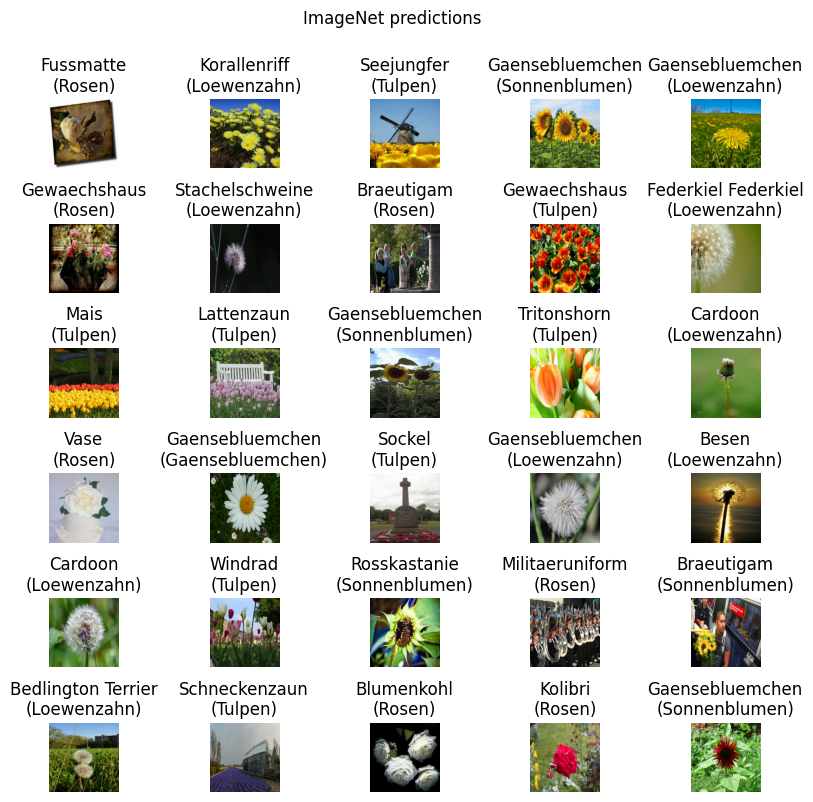

In [70]:
true_label_batch = class_names[labels_batch]
plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.8)
for n in range(30):
    plt.subplot(6,5,n+1)
    plt.imshow(image_batch[n])
    # In Klammern die "echten" Labels
    plt.title(predicted_class_names[n].title() + "\n(" + true_label_batch[n].title() + ")")
    plt.axis('off')
plt.suptitle("ImageNet predictions");

### Ein *Headless Model* laden

Neben den volltrainierten Modellen gibt es auf *TensorFlow Hub* auch Modellvarianten, die zum *Weitertrainieren* bestimmt sind.
Bei diesen Modellen sind die voll-verbundenen *Klassifikationsschichten* nachträglich entfernt.
Die Schichten können nun mit den neuen Daten nachtrainiert werden.
Das bedeutet, wir passen das generelle Modell auf unseren Datensatz an.
Dabei verliert es die Fähigkeit, die vielen vorherigen Klassen zu unterscheiden, gewinnt aber die Fähigkeit, die neuen Klassen zu erkennen.

Alle Modelle unter [diesem Link](https://tfhub.dev/s?module-type=image-feature-vector&q=tf2) können so nachtrainiert werden.

In [71]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

Wir verwenden nun das geladene Modell als *Feature Extractor*. Das heißt als das vortrainierte Modell wird uns die *Eigenschaften* eines Bildes berechnen, die zusätzlichen, neuen Schichten berechnen aus diesen Eigenschaften die zugehörigen Klassen.

Unser *Feature Extractor* wird dabei wie ein Layer zum Keras Modell hinzugefügt.
Damit dieser Teil des Modells nicht mit trainiert wird (er ist ja bereits trainiert), setzen wir den Parameter `trainable=False`.

In [72]:
feature_extractor_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

Der *Feature Extractor* liefert einen Vektor mit 1280 Einträgen, die die *Eigenschaften* des Bildes beschreiben.

In [73]:
feature_batch = feature_extractor_layer(image_batch)
print(feature_batch.shape)

(32, 1280)


### Klassifizierende Schichten ergänzen

Nun fehlen dem Modell noch die End-Schichten, in denen die eigentliche Klassifikation der Bilder geschieht.
Wir fügen dem Modell also noch einen `Dense`-Layer mit fünf Neuronen hinzu, je eines für die zu unterscheidenden Klassen von Blumen.

In [74]:
num_classes = len(class_names)

model = keras.Sequential([
  feature_extractor_layer,
  keras.layers.Dense(num_classes)
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense_1 (Dense)             (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


### Das Modell trainieren

Zunächst kompilieren wir das erstellte Modell.

In [75]:
model.compile(
  optimizer=keras.optimizers.Adam(),
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

Nun verwenden wir die `fit`-Methode, um das Modell zu trainieren. Um das Training möglichst kurz zu halten, werden wir nur zwei Epochen auswerten.

In [76]:
class CollectBatchStats(keras.callbacks.Callback):
    def __init__(self):
        self.batch_losses = []
        self.batch_acc = []

    def on_train_batch_end(self, batch, logs=None):
        self.batch_losses.append(logs['loss'])
        self.batch_acc.append(logs['acc'])
        self.model.reset_metrics()

batch_stats_callback = CollectBatchStats()

history = model.fit(train_ds, epochs=2, callbacks=[batch_stats_callback])

Epoch 1/2
92/92 [==============================] - 11s 68ms/step - loss: 0.0000e+00 - acc: 0.0000e+00
Epoch 2/2
92/92 [==============================] - 4s 39ms/step - loss: 0.0000e+00 - acc: 0.0000e+00


Wir können beobachten, dass nach nur 2 Epochen das Modell bereits gute Ergebnisse liefert.

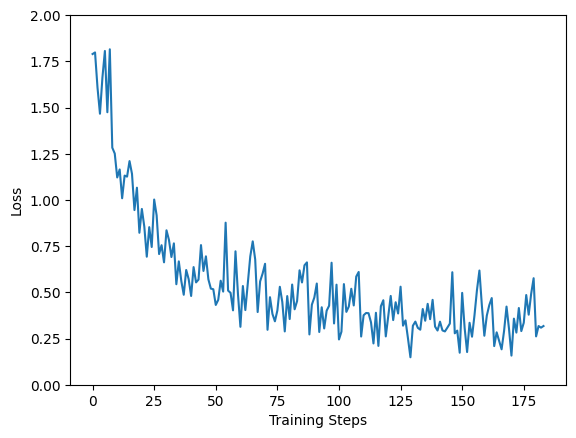

In [77]:
plt.figure()
plt.ylabel("Loss")
plt.xlabel("Training Steps")
plt.ylim([0,2])
plt.plot(batch_stats_callback.batch_losses)

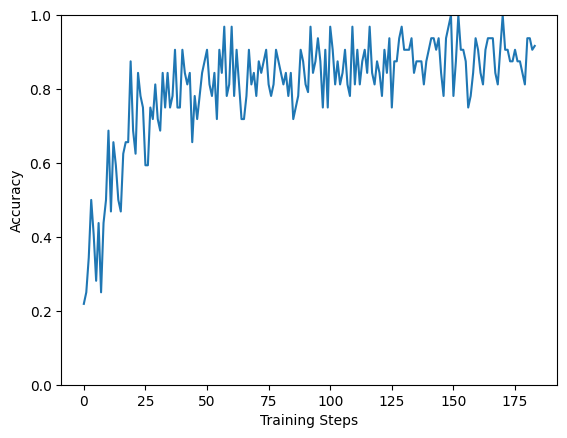

In [78]:
plt.figure()
plt.ylabel("Accuracy")
plt.xlabel("Training Steps")
plt.ylim([0,1])
plt.plot(batch_stats_callback.batch_acc)

### Das Modell überprüfen

Nun können wir unseren Testdaten für den *Flowers* Datensatz erneut auswerten.
Das angepasste Modell sollte nun deutlich bessere Ergebnisse liefern.

1/1 [==============================] - 0s 63ms/step


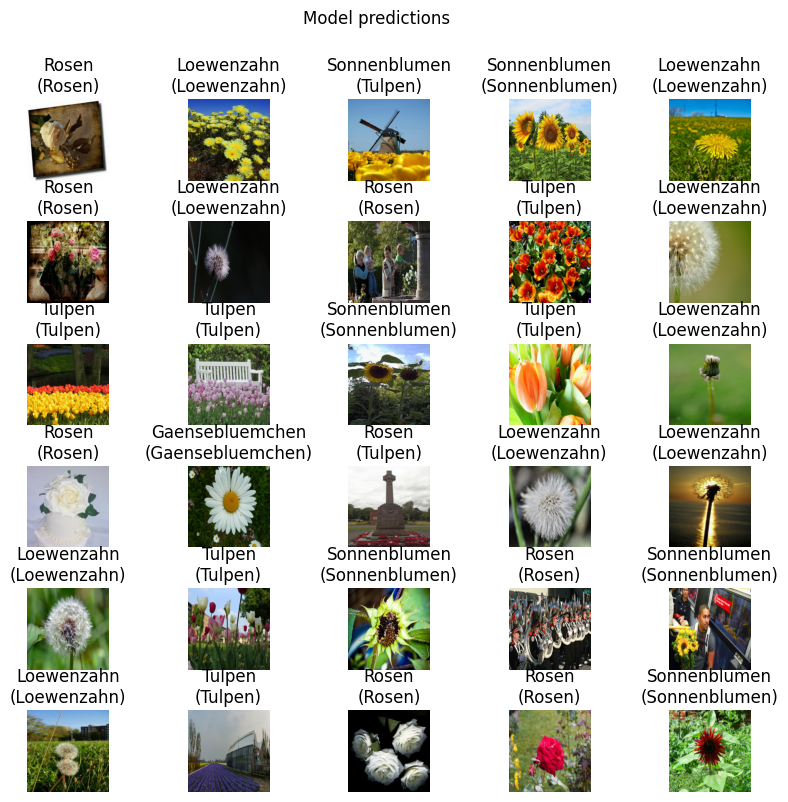

In [85]:
predicted_batch = model.predict(image_batch)
predicted_id = np.argmax(predicted_batch, axis=-1)
predicted_label_batch = class_names[predicted_id]

plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.5)
for n in range(30):
    plt.subplot(6,5,n+1)
    plt.imshow(image_batch[n])
    plt.title(predicted_label_batch[n].title() + "\n(" + true_label_batch[n].title() + ")")
    plt.axis('off')
_ = plt.suptitle("Model predictions")

## Modell abspeichern

Das Trainieren von Modellen ist zeitaufwendig und daher sollte man Ergebnisse immer abspeichern.
Wir exportieren hier das gesamte Tensorflow Modell in einen lokalen Ordner mit aktuellem Zeitstempel.

In [80]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

t = time.time()

export_path = "./{}.keras".format(int(t))
model.save(export_path)

Nun können wir das Modell aus dem abgespeicherten Dateien wiederherstellen.

In [81]:
reloaded = keras.models.load_model(export_path, custom_objects={'KerasLayer': hub.KerasLayer})
reloaded.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense_1 (Dense)             (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [82]:
result_batch = model.predict(image_batch)
reloaded_result_batch = reloaded.predict(image_batch)

1/1 [==============================] - 0s 40ms/step


1/1 [==============================] - 0s 479ms/step


In [83]:

abs(reloaded_result_batch - result_batch).max()

np.float32(0.0)